In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dense,Activation,Dropout,Conv2D,Flatten,MaxPool2D,Reshape,GlobalAveragePooling2D,InputLayer
from tensorflow.keras.applications.resnet import ResNet101
from keras.models import load_model
from keras.applications.vgg19 import VGG19
from keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img,img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
IMAGE_SIZE = [229,229]
path = '/kaggle/input/dataset/train'

In [4]:
train_data_gen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             horizontal_flip = True,
                             validation_split = 0.30)
test_data_gen = ImageDataGenerator(rescale = 1./255,validation_split = 0.30)

In [5]:
training_set = train_data_gen.flow_from_directory(path,
                                                 target_size=(229,229),
                                                 batch_size=100,
                                                 class_mode='binary',
                                                 shuffle=True,
                                                 color_mode='rgb',
                                                 subset = 'training')

testing_set = test_data_gen.flow_from_directory(path,
                                                 target_size=(229,229),
                                                 batch_size=100,
                                                 class_mode='binary',
                                                 shuffle=True,
                                                 color_mode='rgb',
                                                 subset = 'validation')

Found 3463 images belonging to 2 classes.
Found 1483 images belonging to 2 classes.


In [6]:
training_set.class_indices

{'Normal': 0, 'OSCC': 1}

In [7]:
from glob import glob
folders = glob('/kaggle/input/dataset/train/*')
len(folders)

2

In [8]:
base_for_model = resnet.ResNet101(weights='imagenet', input_shape=(229,229,3), include_top=False)

In [9]:
for layer in base_for_model.layers:
    layer.trainable = False

In [10]:
model = Sequential()
model.add(base_for_model) 
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(512, activation='relu'))
model.add(GlobalMaxPooling2D()) 
model.add(BatchNormalization())
model.add(Dense(512, activation = 'relu')) 
model.add(BatchNormalization()) 
model.add(Dense(512,activation='relu'))
model.add(BatchNormalization())
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 229, 229, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 229, 229, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 229, 229, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 114, 114, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 114, 114, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 114, 114, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 57, 57, 128)       0     

In [11]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [12]:
early_stop = EarlyStopping(monitor='val_accuracy', 
                           patience=5,verbose=1,mode='auto')

lr = ReduceLROnPlateau(monitor='val_accuracy', 
                       factor=0.2,patience=5, 
                       min_lr=0.00001)

callback = [early_stop,lr]

In [15]:
result = model.fit_generator(training_set, validation_data=testing_set, epochs=50,
    steps_per_epoch=len(training_set),validation_steps=len(testing_set),callbacks=callback)

Epoch 1/50
35/35 [==============================] - ETA: 0s - loss: 0.5139 - accuracy: 0.7494 - precision: 0.7549 - recall: 0.7497 - auc: 0.8290
Epoch 1: val_loss improved from 0.51719 to 0.46939, saving model to mymodel.hdf5
35/35 [==============================] - 158s 5s/step - loss: 0.5139 - accuracy: 0.7494 - precision: 0.7549 - recall: 0.7497 - auc: 0.8290 - val_loss: 0.4694 - val_accuracy: 0.7883 - val_precision: 0.7720 - val_recall: 0.8274 - val_auc: 0.8694
Epoch 2/50
35/35 [==============================] - ETA: 0s - loss: 0.4857 - accuracy: 0.7675 - precision: 0.7831 - recall: 0.7497 - auc: 0.8484
Epoch 2: val_loss did not improve from 0.46939
35/35 [==============================] - 153s 4s/step - loss: 0.4857 - accuracy: 0.7675 - precision: 0.7831 - recall: 0.7497 - auc: 0.8484 - val_loss: 0.5408 - val_accuracy: 0.7100 - val_precision: 0.6467 - val_recall: 0.9456 - val_auc: 0.8798
Epoch 3/50
35/35 [==============================] - ETA: 0s - loss: 0.4333 - accuracy: 0.8120 

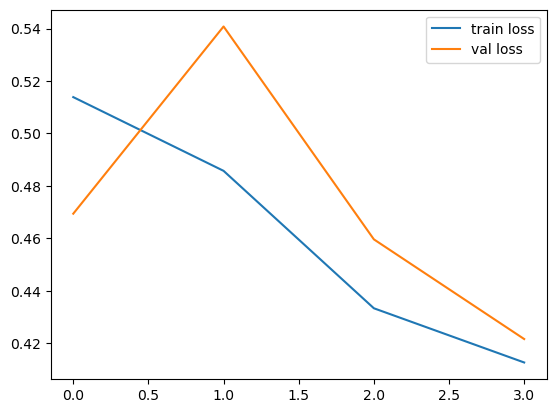

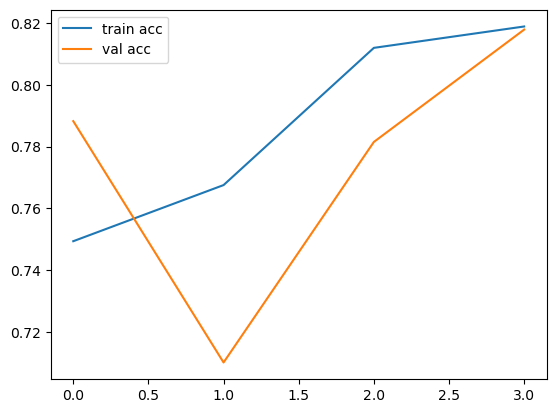

In [16]:
#plot the loss
plt.plot(result.history['loss'], label='train loss')
plt.plot(result.history['val_loss'], label='val loss')
plt.legend()
plt.show()

# plot the accuracy
plt.plot(result.history['accuracy'], label='train acc')
plt.plot(result.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()

In [ ]:
model.save('cancer.h5')

In [17]:
print("The accuracy of the model:{:.2f} %".format(result.history['accuracy'][-1]*100))
print("The accuracy of the testing:{:.2f} %".format(result.history['val_accuracy'][-1]*100))

The accuracy of the model:81.89 %
The accuracy of the testing:81.79 %


In [18]:
classes = []
for i,j in enumerate(testing_set.class_indices):
    classes.append(j)

In [19]:
#model = load_model('./cancer.h5')
def testing(img):
    img = image.load_img(img,target_size=(229,229)) 
    x = image.img_to_array(img) 
    x = np.expand_dims(x,axis=0) 
    pred = model.predict(x)
    print(pred[0][0])
    if pred < 0.5:
        print("Normal")
    else:
        print("Affected")


def img_show(img):
    img1 = image.load_img(img,target_size=(229,229)) 
    plt.imshow(img1)

1/1 [==============================] - 1s 956ms/step
1.0
Affected


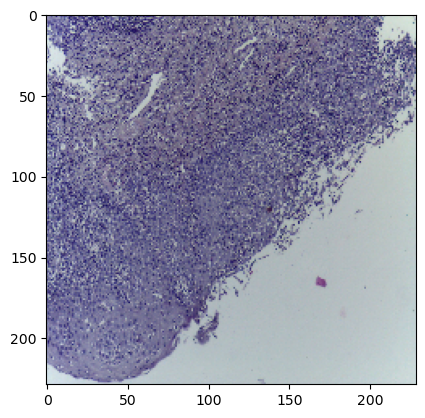

In [20]:
testing('/kaggle/input/dataset/val/OSCC/OSCC_100x_258.jpg')
img_show('/kaggle/input/dataset/val/OSCC/OSCC_100x_258.jpg')